<a href="https://colab.research.google.com/github/ShreyanshSrivastava01/Project_Vertex/blob/main/ProjectTitanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   PassengerId  Survived  Pclass                          Name     Sex  Age  \
0            1         0       3       Braund, Mr. Owen Harris    male   22   
1            2         1       1    Cumings, Mrs. John Bradley  female   38   
2            3         1       3        Heikkinen, Miss. Laina  female   26   
3            4         1       1  Futrelle, Mrs. Jacques Heath  female   35   
4            5         0       3      Allen, Mr. William Henry    male   35   

   SibSp  Parch            Ticket     Fare Cabin Embarked  
0      1      0         A/5 21171   7.2500   C61        S  
1      1      0          PC 17599  71.2833   C85        C  
2      0      0  STON/O2. 3101282   7.9250   C97        S  
3      1      0            113803  53.1000  C123        S  
4      0      0            373450   8.0500  C142        S  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       ----

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


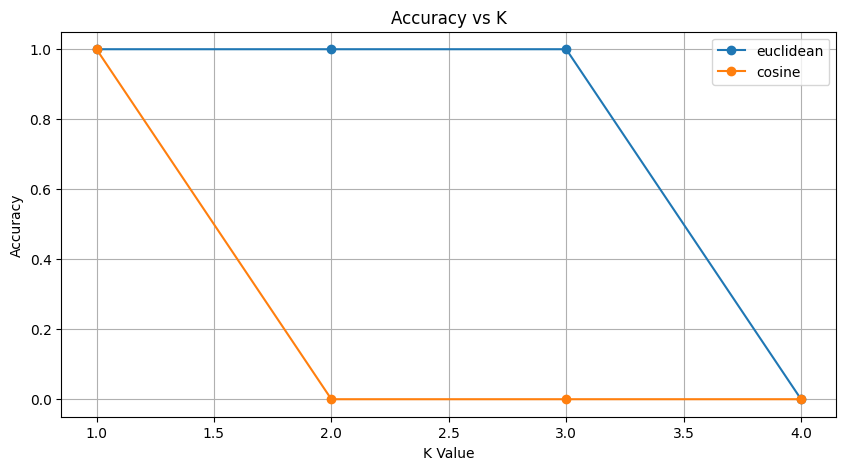


========== Model Comparison ==========

                 Model  Accuracy
0  Logistic Regression       1.0
1                  KNN       1.0

Both models performed equally.


In [2]:
# ==========================================
# Titanic Survival Prediction using
# KNN + Logistic Regression
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================================
# Load Dataset
# ==========================================
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Project_Titanic/titanic.csv")

# ==========================================
# Explore Dataset
# ==========================================
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

# ==========================================
# Data Cleaning
# ==========================================
df.drop(['Cabin','Name','Ticket'], axis=1, inplace=True)

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# ==========================================
# Encoding
# ==========================================
df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)

# ==========================================
# Feature & Target
# ==========================================
X = df.drop('Survived', axis=1)
y = df['Survived']

# ==========================================
# Feature Scaling
# ==========================================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# Train Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Logistic Regression
# ==========================================
print("\n========== Logistic Regression ==========\n")

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy :", lr_accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

# ==========================================
# KNN
# Find Best K and Best Metric
# ==========================================

metrics = ['euclidean', 'cosine']

results = []

best_accuracy = 0
best_k = 0
best_metric = ""

# Limit k to the number of training samples to avoid error with small dataset
max_k = len(X_train)

for metric in metrics:

    for k in range(1, max_k + 1):

        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        knn.fit(X_train, y_train)

        pred = knn.predict(X_test)

        acc = accuracy_score(y_test, pred)

        results.append([k, metric, acc])

        if acc > best_accuracy:

            best_accuracy = acc
            best_k = k
            best_metric = metric

print("\n========== Best KNN ==========\n")

print("Best K :", best_k)
print("Best Metric :", best_metric)
print("Best Accuracy :", best_accuracy)

# ==========================================
# Final KNN Model
# ==========================================

best_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric=best_metric
)

best_knn.fit(X_train, y_train)

knn_pred = best_knn.predict(X_test)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

# ==========================================
# Accuracy vs K Graph
# ==========================================

plt.figure(figsize=(10,5))

for metric in metrics:

    acc = []
    for k in range(1, max_k + 1):

        model = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        acc.append(accuracy_score(y_test, pred))

    plt.plot(range(1, max_k + 1), acc, marker='o', label=metric)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy":[
        lr_accuracy,
        best_accuracy
    ]
})

print("\n========== Model Comparison ==========\n")
print(comparison)

if best_accuracy > lr_accuracy:
    print("\nKNN performed better than Logistic Regression.")
elif lr_accuracy > best_accuracy:
    print("\nLogistic Regression performed better than KNN.")
else:
    print("\nBoth models performed equally.")